<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Сегментация изображений</b></h3>


В этом задании вам предстоит решить задачу сегментации медицинских снимков. Домашнее задание можно разделить на следующие части:

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]
* Мир других лоссов! [2]
  * Dice Loss [1]
  * Focal Loss [1]
  * BONUS: лосс из статьи [5]
* Новая модель! [2]
  * UNet [2]


**Максимальный балл:** 10 баллов.

Также для студентов желающих еще более углубиться в задачу предлагается решить бонусное задание, которое даст дополнительные 5 баллов. BONUS задание необязательное.


# Шаг 1. Загрузка и подготовка данных

1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>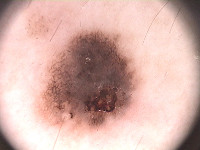</td><td>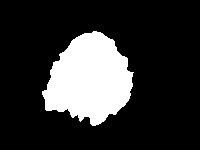</td></tr></table>

2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

In [1]:
!gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

Downloading...
From (original): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql
From (redirected): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql&confirm=t&uuid=e65066f7-951b-4655-ad7b-2a6fd3f2973f
To: /kaggle/working/PH2Dataset.rar
100%|█████████████████████████████████████████| 162M/162M [00:01<00:00, 102MB/s]


In [2]:
get_ipython().system_raw("unrar x PH2Dataset.rar")


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from PH2Dataset.rar

Creating    PH2Dataset                                                OK
Creating    PH2Dataset/PH2 Dataset images                             OK
Creating    PH2Dataset/PH2 Dataset images/IMD002                      OK
Creating    PH2Dataset/PH2 Dataset images/IMD002/IMD002_Dermoscopic_Image  OK
Extracting  PH2Dataset/PH2 Dataset images/IMD002/IMD002_Dermoscopic_Image/IMD002.bmp     0  OK 
Creating    PH2Dataset/PH2 Dataset images/IMD002/IMD002_lesion        OK
Extracting  PH2Dataset/PH2 Dataset images/IMD002/IMD002_lesion/IMD002_lesion.bmp     0  OK 
Creating    PH2Dataset/PH2 Dataset images/IMD002/IMD002_roi           OK
Extracting  PH2Dataset/PH2 Dataset images/IMD002/IMD002_roi/IMD002_R1_Label4.bmp     0  OK 
Extracting  PH2Dataset/PH2 Dataset images/IMD002/IMD002_roi/IMD002_R2_Label3.bmp     0  OK 
Creating    PH2Dataset/PH2 Dataset images/IMD003                      OK
Crea

Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [3]:
images = []
lesions = []
from skimage.io import imread
import os
root = 'PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

Изображения имеют разные размеры. Давайте изменим их размер на $256\times256 $ пикселей. Для изменения размера изображений можно использовать [`skimage.transform.resize()`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize).
Эта функция также автоматически нормализует изображения в диапазоне $[0,1]$.


In [4]:
from skimage.transform import resize
size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True,) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

In [5]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

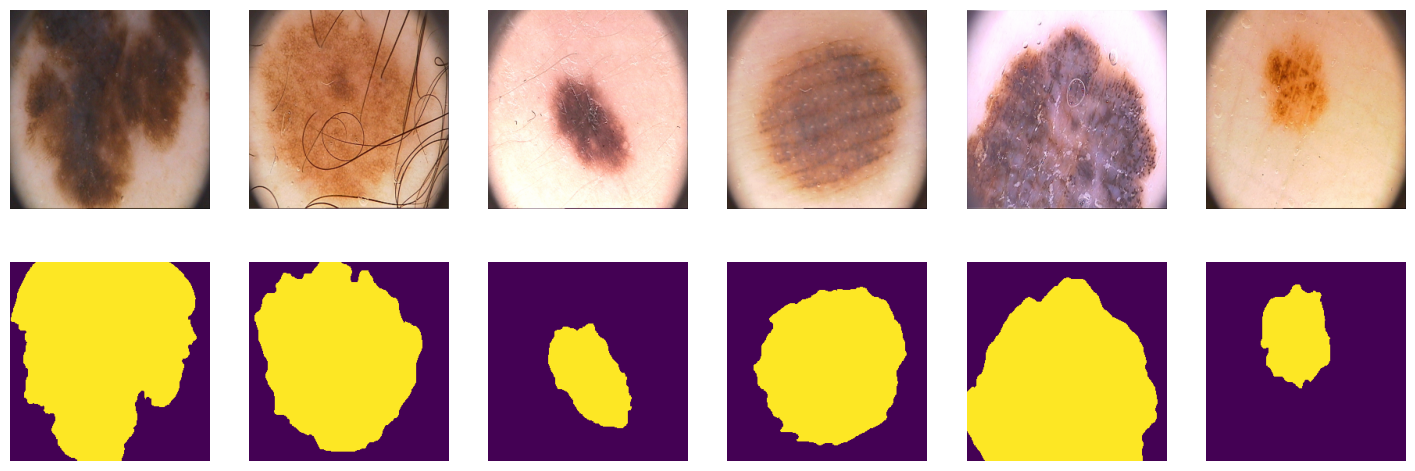

In [6]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

Разделим наши 200 картинок на 100/50/50
 для обучения, валидации и теста соответственно

In [7]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])

In [8]:
print(len(tr), len(val), len(ts))

100 50 50


## PyTorch DataLoader

In [9]:
from torch.utils.data import DataLoader
batch_size = 25
train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
                     batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                      batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                     batch_size=batch_size, shuffle=False)

In [10]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Шаг 2. Метрика качества модели

## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:



In [11]:
!pip install torchmetrics

In [12]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)

# Задания: Построй свой первый бейзлайн!

Итак, загрузка файлов, код датасета и даталоадера написана за вас. Метрика IoU написана за вас! Вам остается написать лосс, модель и функции обучения и теста модели.

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]

## Шаг 3. Loss функция - BCE [2 балла]

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

### Вывод численно стабильной формулы BCE лосса [1 балл]



Выведите из формулы [1] формулу [2]:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

Не забываем, что здесь $\hat y_i$ - это логиты сети, не вероятности и не лейблы.

**Ответ**:

Сигмоида - $\sigma(\hat y) = \frac{1}{1 + e^{-\hat y}}$.

---

**Логарифмы сигмоиды через логит**

$$
\begin{aligned}
\log \sigma(\hat y) &= \log \frac{1}{1 + e^{-\hat y}} = -\log(1 + e^{-\hat y}), \\
\log \big(1 - \sigma(\hat y)\big) &= \log \frac{e^{-\hat y}}{1 + e^{-\hat y}}
= \log e^{-\hat y} - \log(1 + e^{-\hat y})
= -\hat y - \log(1 + e^{-\hat y}).
\end{aligned}
$$

---

**Подстановка в [1]**

Подставляем оба логарифма:

$$
\mathcal L = -\Big[ y \big(-\log(1 + e^{-\hat y})\big) + (1-y) \big(-\hat y - \log(1 + e^{-\hat y})\big) \Big].
$$

Раскрываем внутренние скобки:

$$
\mathcal L = -\Big[ -y \log(1 + e^{-\hat y}) - (1-y)\hat y - (1-y) \log(1 + e^{-\hat y}) \Big].
$$

Группируем слагаемые:

$$
-y \log(1 + e^{-\hat y}) - (1-y) \log(1 + e^{-\hat y}) = -\log(1 + e^{-\hat y}).
$$

Упрощаем:

$$
\mathcal L = -\Big[ -\log(1 + e^{-\hat y}) - (1-y)\hat y \Big]
= \log(1 + e^{-\hat y}) + (1-y)\hat y.
$$

---

**Приведение к итоговому виду**

Раскрываем скобку $(1-y)\hat y = \hat y - y\hat y$:

$$
\mathcal L = \hat y - y\hat y + \log(1 + e^{-\hat y}). \tag{2}
$$

### Реализуйте в коде оба варианта лосса [1 балл]

Реализуйте следующие функции:

*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация формулы, которую мы вывели $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравните результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`

In [13]:
import torch.nn.functional as F
import torch.nn as nn

In [14]:
bce_torch = nn.BCELoss(reduction='sum') # (sigmoid(y_pred), y_real)
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

In [15]:
def bce_loss(y_pred, y_real):
    # log(1+exp(-x)) = softplus(-x)
    loss = y_pred - y_real * y_pred + F.softplus(-y_pred)
    return loss.sum()

def bce_true(y_pred, y_real):
    prob = torch.sigmoid(y_pred)
    # Ограничиваем вероятности, чтобы не было log(0)
    eps = 1e-15
    prob = torch.clamp(prob, eps, 1 - eps)
    loss = -(y_real * torch.log(prob) + (1 - y_real) * torch.log(1 - prob))
    return loss.sum()

Проверим корректность работы на простом примере

In [16]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(f'BCE loss from scratch bce_loss             = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный                = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch              = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits bce_torch  = {bce_torch_with_logits(y_pred, y_true)}')


BCE loss from scratch bce_loss             = 3.6728734970092773
BCE loss честно посчитанный                = 3.6728734970092773
BCE loss from torch bce_torch              = 3.6728734970092773
BCE loss from torch with logits bce_torch  = 3.6728734970092773


Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности нашего кода.

In [17]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

In [18]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss            = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный               = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch             = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

BCE loss from scratch bce_loss            = 15.218299865722656
BCE loss честно посчитанный               = 15.218299865722656
BCE loss from torch bce_torch             = 15.218299865722656
BCE loss from torch with logits bce_torch = 15.218299865722656


In [19]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

Давайте посчитаем на реальных логитах и сегментационной маске:

In [20]:
!gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

Retrieving folder contents
Processing file 1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC labels.pt
Processing file 1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I logits.pt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC
To: /kaggle/working/for_asserts/labels.pt
100%|██████████████████████████████████████| 1.18k/1.18k [00:00<00:00, 6.83MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I
To: /kaggle/working/for_asserts/logits.pt
100%|██████████████████████████████████████| 1.18k/1.18k [00:00<00:00, 7.50MB/s]
Download completed


In [21]:
path_to_dummy_samples = '/kaggle/working/for_asserts'
dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to(device)
dummpy_sample['logits'] = dummpy_sample['logits'].to(device)

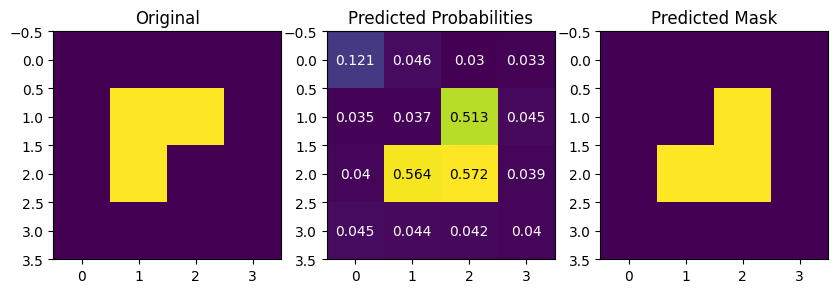

In [22]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

Проверяем на данном примере:

In [23]:
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu().float())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

## Шаг 4. Модель SegNet [2 балла]

Ваше задание здесь состоит в том, чтобы реализовать SegNet архитектуру.

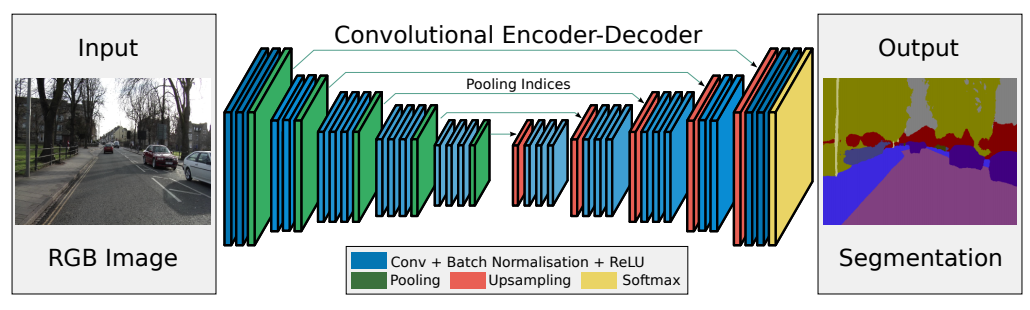

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

Внимательно посмотрите из чего состоит модель и для чего выбраны те или иные блоки. Для этого скачаем и изучим feature extractor VGG-16, который лежит в основе SegNet.

In [25]:
model_vgg16 = models.vgg16(weights = models.VGG16_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 184MB/s]  


In [26]:
model_vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Feature extractor VGG-16 состоит из 5 блоков:
- два блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d
- три блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d

В первом блоке - на входе три канала (по числу каналов в изображениях), которые конволюционный слой преобразует в 64 канала.

Во втором, третьем и четвертом блоках первый конволюционный слой удваивает количество каналов, а последующие конволюционные слои не меняют количество каналов.

В последнем блоке число каналов от слоя к слою не меняется.

Теперь напишем код одного блока энкодера нашей модели SegNet.  

In [27]:
# Параметрами блока будут:
# - количество каналов на входе
# - количество каналов на выходе
# - глубина блока (2 или 3, по количеству конволюционных слоев)
# - kernel_size и padding
#
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(EncoderBlock, self).__init__() # инициируем экземляр класса, наследующего от nn.Module
        self.layers = nn.ModuleList() # в self.layers будем добавлять слои блока
        # дальше реализуем то, что на картинке выше обозначено Conv + Batch Normalization + ReLU
        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        # цикл for помогает использовать один код для блоков как с глубиной 2, так и с глубиной 3
        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.maxpooling = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) #добавляем MaxPool с индексами для последующего Unpooling

    # Обратите внимание: на вход метод forward() получает карту признаков (х),
    # а возвращает карту признаков и индексы для последующего Unpooling
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x, indices = self.maxpooling(x)
        return x, indices


По аналогии напишите код одного блока декодера.

К карте признаков на входе каждого блока примеяется nn.MaxUnpool2d с индексами из симметричного блока энкодера. Затем повторяется связка Conv + Batch Normalization + ReLU. Количество каналов меняется зеркально блокам энкодера:
- в первом блоке декодера количество каналов не меняется
- во 2-4 блоках декодера количество каналов уменьшается в 2 раза после прохождения последнего конволюционного слоя
- на выходе из последнего блока декодера 1 канал

Обратите внимание, что после последней конволюции последнего блока декодера не применяется батч-нормализация и функция активации.

In [28]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size=3, padding=1, last_block=False):
        '''
        Блок декодера SegNet
        
        Параметры:
        - in_channels: число каналов на входе;
        - out_channels: число каналов на выходе (после последней свёртки);
        - depth: количество конволюционных слоёв (2 или 3);
        - kernel_size: размер ядра свёртки;
        - padding: паддинг свёртки;
        - last_block: если True, то после последней свёртки не применяются BatchNorm и ReLU.
        '''
        super(DecoderBlock, self).__init__()
        
        self.layers = nn.ModuleList()
        
        # Первые свёртки не меняют число каналов
        for _ in range(depth - 1):
            self.layers.append(nn.Conv2d(in_channels, in_channels, kernel_size=kernel_size, padding=padding))
            self.layers.append(nn.BatchNorm2d(in_channels))
            self.layers.append(nn.ReLU(inplace=True))
        
        # Последняя свёртка: меняет число каналов с in_channels на out_channels
        self.layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding))
        if not last_block:
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))
        
        # Анпулинг с использованием индексов из симметричного энкодер-блока
        self.maxunpool = nn.MaxUnpool2d(kernel_size=2, stride=2)
    
    def forward(self, x, indices):
        # Восстановление пространственного разрешения
        x = self.maxunpool(x, indices)
        # Последовательное применение свёрток, BatchNorm и ReLU
        for layer in self.layers:
            x = layer(x)
        return x

Соединим блоки энкодера и декодера в модель SegNet:

In [29]:
class SegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, num_features=64) -> None:
        super(SegNet, self).__init__()

        # Encoder
        self.encoder0 = EncoderBlock(in_channels, num_features, depth=2)
        self.encoder1 = EncoderBlock(num_features, num_features * 2, depth=2)
        self.encoder2 = EncoderBlock(num_features * 2, num_features * 4, depth=3)
        self.encoder3 = EncoderBlock(num_features * 4, num_features * 8, depth=3)

        # Encoder bottleneck - количество каналов на входе и на выходе одинаково
        self.encoder4 = EncoderBlock(num_features * 8, num_features * 8, depth=3)

        # Decoder bottleneck
        self.decoder0 = DecoderBlock(num_features * 8, num_features * 8, depth=3, last_block=False)

        # Decoder
        self.decoder1 = DecoderBlock(num_features * 8, num_features * 4, depth=3, last_block=False)
        self.decoder2 = DecoderBlock(num_features * 4, num_features * 2, depth=3, last_block=False)
        self.decoder3 = DecoderBlock(num_features * 2, num_features, depth=2, last_block=False)
        self.decoder4 = DecoderBlock(num_features, out_channels, depth=2, last_block=True)

    def forward(self, x):
        # encoder
        x, indices0 = self.encoder0(x)
        x, indices1 = self.encoder1(x)
        x, indices2 = self.encoder2(x)
        x, indices3 = self.encoder3(x)
        x, indices4 = self.encoder4(x)

        # decoder
        x = self.decoder0(x, indices4)
        x = self.decoder1(x, indices3)
        x = self.decoder2(x, indices2)
        x = self.decoder3(x, indices1)
        output = self.decoder4(x, indices0)

        return output  # no activation

## Шаг 5. Тренировка модели [1 балл]

Напишите функции для обучения модели.

In [30]:
from tqdm.notebook import tqdm

In [31]:
def train_one_epoch(model, dataloader, optimizer, criterion, device, epoch=None):
    '''
    Один проход обучения.
    Возвращает среднее значение функции потерь за эпоху.
    '''
    model.train()
    running_loss = 0.0

    desc = f'Эпоха {epoch}' if epoch is not None else 'Обучение..'
    loop = tqdm(dataloader, desc=desc, leave=False)
    for images, masks in loop:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        loop.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss

@torch.no_grad()
def validate(model, dataloader, criterion, device, threshold=0.5):
    '''
    Валидация с подсчётом лосса и IoU.
    Возвращает кортеж (val_loss, val_iou).
    '''
    model.eval()

    # Инициализируем метрику IoU
    iou_metric = JaccardIndex(
        threshold=threshold,
        task="binary",
        average='none'
    ).to(device)

    running_loss = 0.0
    running_iou = 0.0

    loop = tqdm(dataloader, desc="Validation", leave=False)
    for images, masks in loop:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)

        # IoU для батча
        batch_iou = iou_metric(outputs, masks)   # тензор формы (batch_size,)
        batch_iou_mean = batch_iou.mean().item()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        running_iou += batch_iou_mean * batch_size

        loop.set_postfix(loss=loss.item(), IoU=batch_iou_mean)

    val_loss = running_loss / len(dataloader.dataset)
    val_iou = running_iou / len(dataloader.dataset)
    return val_loss, val_iou

Обучите модель **SegNet**. В качестве оптимайзера можно взять Adam.

In [32]:
model = SegNet(in_channels=3, out_channels=1).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 30

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_dataloader, optimizer, criterion, device, epoch)
    val_loss, val_iou = validate(model, valid_dataloader, criterion, device)

    print(f'Эпоха {epoch}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f}')

Эпоха 1:   0%|          | 0/4 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Эпоха 1/30 | Train Loss: 0.7015 | Val Loss: 0.6913 | Val IoU: 0.0111


Эпоха 2:   0%|          | 0/4 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Эпоха 29/30 | Train Loss: 0.1629 | Val Loss: 0.2785 | Val IoU: 0.7264


Эпоха 30:   0%|          | 0/4 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Эпоха 30/30 | Train Loss: 0.1390 | Val Loss: 0.1685 | Val IoU: 0.8212


## Шаг 6. Инференс [1 балл]

После обучения модели напишите функцию теста, воспользуйтесь лучшим чекпоинтом и протестируйте работу модели на тестовой выборке.

In [33]:
@torch.no_grad()
def test(model, dataloader, criterion, device, threshold=0.5):
    '''
    Тестирование модели на тестовом наборе данных
    
    Возвращает:
    - test_loss: средний BCE лосс;
    - test_iou: средний IoU.
    '''
    model.eval()
    
    # Метрика IoU
    iou_metric = JaccardIndex(
        threshold=threshold,
        task="binary",
        average='none'
    ).to(device)
    
    running_loss = 0.0
    running_iou = 0.0
    
    loop = tqdm(dataloader, desc="Testing", leave=True)
    for images, masks in loop:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        
        loss = criterion(outputs, masks)
        batch_iou = iou_metric(outputs, masks).mean().item()
        
        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        running_iou += batch_iou * batch_size
        
        loop.set_postfix(loss=loss.item(), IoU=batch_iou)
    
    test_loss = running_loss / len(dataloader.dataset)
    test_iou = running_iou / len(dataloader.dataset)
    
    return test_loss, test_iou

In [34]:
test_loss, test_iou = test(model, test_dataloader, criterion, device)

print(f"Тест (модель после {num_epochs} эпох):")
print(f"  Loss: {test_loss:.4f}")
print(f"  IoU : {test_iou:.4f}")

Testing:   0%|          | 0/2 [00:00<?, ?it/s]

Тест (модель после 30 эпох):
  Loss: 0.1676
  IoU : 0.8321


# Задания: Мир других лоссов!

## Пробуем другие функции потерь [2 балла]

В данном разделе вам потребуется имплементировать две функции потерь: DICE и Focal loss.


### Dice Loss

**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

Итак, давайте сначала пропишем dice_score.

In [35]:
def dice_score(logits: torch.Tensor, labels: torch.Tensor, threshold = 0.5, eps = 1e-8) -> torch.Tensor:
    '''
    Вычисляет Dice-метрику (не лосс) для бинарной сегментации

    Args:
    - logits: сырые выходы модели, форма (N, 1, H, W) или (N, H, W);
    - labels: истинные маски, форма (N, 1, H, W) или (N, H, W), значения 0/1;
    - threshold: порог бинаризации вероятностей;
    - eps: константа для численной стабильности;

    Returns:
    - Скалярный тензор со значением Dice-коэффициента
    '''
    # Преобразуем логиты в вероятности
    probs = torch.sigmoid(logits)

    # Бинаризуем по порогу
    preds = (probs > threshold).float()

    # Приводим таргет к float и одинаковой размерности
    labels = labels.float()

    # Считаем агрегаты по всему батчу
    intersection = (preds * labels).sum()
    sum_preds = preds.sum()
    sum_labels = labels.sum()

    # Dice-коэффициент с численной стабилизацией
    dice = (2.0 * intersection + eps) / (sum_preds + sum_labels + eps)

    return dice

Проверим на корректность функцию dice_score:

In [36]:
from torchmetrics.segmentation import DiceScore

dice = DiceScore(num_classes=1, average='micro').to(device)
dice((dummpy_sample['logits'].sigmoid() > 0.5).float(), dummpy_sample['labels'].to(int))

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)


tensor(0.3158, device='cuda:0')

Давайте теперь пропишем лосс и воспользуемся библиотекой `segmentation-models-pytorch`, чтобы убедиться в корректности нашей функции.

In [37]:
def dice_loss(logits: torch.Tensor, labels: torch.Tensor, smooth = 1e-8):
    '''
    Dice-loss (дифференцируемая версия для обучения)
    
    Аргументы:
    - logits: выход модели (B, 1, H, W) или (B, H, W);
    - labels: истинная бинарная маска той же размерности со значениями 0 или 1;
    - smooth: небольшая константа для численной стабильности.
    
    Returns:
    - Тензор с одним значением loss (средний по батчу)
    '''
    # Сигмоида для получения вероятностей
    probs = torch.sigmoid(logits)
    labels = labels.float()

    # Суммируем по всем осям, кроме batch
    dims = tuple(range(1, probs.ndim))

    # Мягкие TP, FP, FN
    TP = (probs * labels).sum(dim=dims)
    FP = (probs * (1 - labels)).sum(dim=dims)
    FN = ((1 - probs) * labels).sum(dim=dims)

    # Dice-коэффициент для каждого примера
    dice = (2 * TP + smooth) / (2 * TP + FP + FN + smooth)

    # Loss = 1 - Dice, усреднённый по батчу
    loss = 1 - dice.mean()
    return loss

Проверка на корректность:

In [38]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.0 MB/s eta 0:00:0000:01


In [39]:
from segmentation_models_pytorch.losses import DiceLoss
dice_loss_torch = DiceLoss(mode='binary')
dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.5756, device='cuda:0')

In [40]:
assert dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int)) == dice_loss(dummpy_sample['logits'], dummpy_sample['labels'])

### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

In [48]:
def focal_loss(y_real: torch.Tensor, y_pred: torch.Tensor, eps = 1e-8, gamma = 2.0) -> torch.Tensor:
    '''
    Focal Loss для бинарной классификации

    Args:
    - y_real: истинные метки (0/1) той же размерности, что и y_pred;
    - y_pred: вероятности предсказаний (после сигмоиды) в диапазоне [0, 1];
    - eps: небольшая константа для избежания log(0);
    - gamma: фокусирующий параметр (>0);

    Returns:
    - Скалярный тензор со значением focal loss (среднее по всем элементам)
    '''
    probs = torch.sigmoid(y_pred)
    y_real = y_real.float()
    p_t = y_real * probs + (1 - y_real) * (1 - probs)
    p_t = torch.clamp(p_t, eps, 1.0 - eps)
    loss = - (1 - p_t) ** gamma * torch.log(p_t)
    return loss.sum()

Проверка корректности функции:

In [49]:
from torchvision.ops import sigmoid_focal_loss
sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum')

tensor(3.6161, device='cuda:0')

In [50]:
val1 = sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum')
val2 = focal_loss(dummpy_sample['labels'], dummpy_sample['logits'], gamma=2.0)
assert torch.allclose(val1, val2, atol=1e-6)

## Обучите SegNet на новых лоссах

**Задание**: обучите SegNet на новых лоссах и сравните все три лосса:
*   При каком лоссе модель сходится быстрее?
*   При каком лоссе модель выдает наилучшую метрику?

Напишите развернутый ответ на вопросы.



In [52]:
from segmentation_models_pytorch.losses import DiceLoss, FocalLoss

In [55]:
from collections import defaultdict

In [56]:
loss_functions = {
    'BCE': nn.BCEWithLogitsLoss(),
    'Dice': DiceLoss(mode='binary', from_logits=True),
    'Focal': FocalLoss(mode='binary', gamma=2.0, alpha=0.25)
}

num_epochs = 30

trained_models = {}
history = defaultdict(dict)

for loss_name, criterion in loss_functions.items():
    print(f"\n{'='*50}")
    print(f"Обучение с {loss_name}")
    print('='*50)

    # Создаём новую модель и оптимизатор
    model = SegNet(in_channels=3, out_channels=1).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    train_losses, val_losses, val_ious = [], [], []

    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch(model, train_dataloader, optimizer, criterion, device, epoch)
        val_loss, val_iou = validate(model, valid_dataloader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_ious.append(val_iou)

        print(f'Эпоха {epoch}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f}')

    # Сохраняем модель и историю
    trained_models[loss_name] = model
    history[loss_name]['train_loss'] = train_losses
    history[loss_name]['val_loss'] = val_losses
    history[loss_name]['val_iou'] = val_ious

    # Оценка на тесте
    test_loss, test_iou = test(model, test_dataloader, criterion, device)
    history[loss_name]['test_loss'] = test_loss
    history[loss_name]['test_iou'] = test_iou
    print(f"\n>>> {loss_name} на тесте: Loss={test_loss:.4f}, IoU={test_iou:.4f}")


Обучение с BCE


Эпоха 1:   0%|          | 0/4 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Эпоха 1/30 | Train Loss: 0.6605 | Val Loss: 0.6845 | Val IoU: 0.0000


Эпоха 2:   0%|          | 0/4 [00:00<?, ?it/s]

...

Эпоха 30:   0%|          | 0/4 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Эпоха 30/30 | Train Loss: 0.0109 | Val Loss: 0.0134 | Val IoU: 0.7922


Testing:   0%|          | 0/2 [00:00<?, ?it/s]


>>> Focal на тесте: Loss=0.0148, IoU=0.7946


### Сходится быстрее - BCE (раньше всех выходит на высокий IoU);


### Наилучшая метрика - тоже BCE (максимальный IoU на тесте и валидации).


### Видимо, этот датасет не страдает от сильного дисбаланса классов, поэтому стандартный BCE дал самую быструю сходимость и лучший итоговый IoU. Focal Loss с alpha=0.25 излишне подавлял градиенты положительного класса, из-за чего модель долго не могла выйти из нулевого IoU, а Dice Loss показал нестабильное поведение. Таким образом, специализированные лоссы не дали преимущества, потому что не соответствовали характеру распределения классов в данных.

# Задание: Новая модель!

## Модель U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

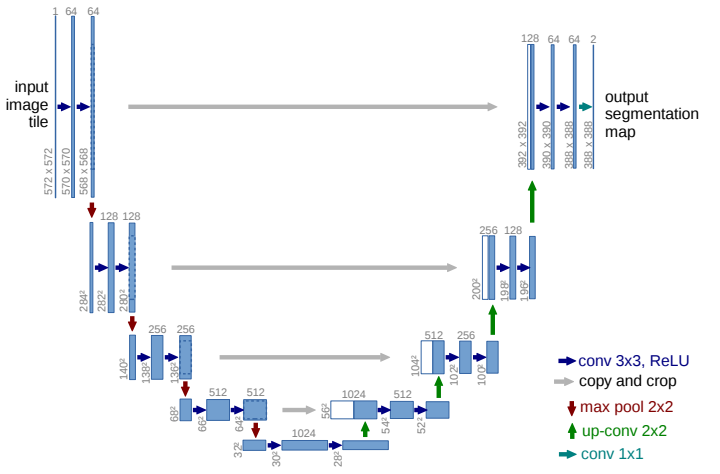

У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

В оригинальной статье авторы не использовали padding внутри модели (это видно по тому, что размеры карты признаков уменьшаются на 2 каждый раз при движении от слоя к слою). При этом размеры входных изображений авторы единоразово увеличили при помощи mirror padding.

В этом домашнем задании вы можете применить альтернативный подход - сохранять размеры карт признаков при помощью padding = 1 во внутренних слоях.  

In [58]:
import torch.nn.functional as F
import torch.nn as nn

Для реализации UNet вы можете написать классы блоков энкодера и декодера отдельно, как мы сделали при реализации SegNet.

In [64]:
class DoubleConv(nn.Module):
    '''Двойная свёртка (conv -> BN -> ReLU) * 2 '''
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base_filters=64):
        super().__init__()
        # Энкодер
        self.enc1 = DoubleConv(in_channels, base_filters)
        self.enc2 = DoubleConv(base_filters, base_filters * 2)
        self.enc3 = DoubleConv(base_filters * 2, base_filters * 4)
        self.enc4 = DoubleConv(base_filters * 4, base_filters * 8)
        self.pool = nn.MaxPool2d(2, 2)

        # Bottleneck
        self.bottleneck = DoubleConv(base_filters * 8, base_filters * 16)

        # Декодер
        self.up4 = nn.ConvTranspose2d(base_filters * 16, base_filters * 8, 2, stride=2)
        self.dec4 = DoubleConv(base_filters * 16, base_filters * 8)

        self.up3 = nn.ConvTranspose2d(base_filters * 8, base_filters * 4, 2, stride=2)
        self.dec3 = DoubleConv(base_filters * 8, base_filters * 4)

        self.up2 = nn.ConvTranspose2d(base_filters * 4, base_filters * 2, 2, stride=2)
        self.dec2 = DoubleConv(base_filters * 4, base_filters * 2)

        self.up1 = nn.ConvTranspose2d(base_filters * 2, base_filters, 2, stride=2)
        self.dec1 = DoubleConv(base_filters * 2, base_filters)

        # Выходной слой с out_channels
        self.out_conv = nn.Conv2d(base_filters, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)

In [66]:
unet_model = UNet().to(device)

## Обучите UNet

Задание: обучите UNet на всех трех лоссах: BCE, Dice, Focal и сравните результаты с SegNet:
*   Какая модель дает лучшие значения по метрике?
*   Какая модель дает лучшие значения по лоссам?
*   Какая модель обучается быстрее?
*   Сравните визуально результаты SegNet и UNet.

Напишите развернутый ответ на вопросы.



In [67]:
loss_functions = {
    'BCE': nn.BCEWithLogitsLoss(),
    'Dice': DiceLoss(mode='binary', from_logits=True),
    'Focal': FocalLoss(mode='binary', gamma=2.0, alpha=0.25)
}

num_epochs = 20

# словарь для сохранения обученных моделей
trained_models = {}  

for arch_name, model_class in zip(['SegNet', 'UNet'], [SegNet, UNet]):
    print(f"\n{'='*60}")
    print(f"Архитектура: {arch_name}")
    print('='*60)
    history[arch_name] = {}
    
    for loss_name, criterion in loss_functions.items():
        print(f"\n--- Loss: {loss_name} ---")
        model = model_class(in_channels=3, out_channels=1).to(device)
        optimizer = optim.Adam(model.parameters(), lr=1e-4)
        
        train_losses, val_losses, val_ious = [], [], []
        for epoch in range(1, num_epochs+1):
            train_loss = train_one_epoch(model, train_dataloader, optimizer, criterion, device, epoch)
            val_loss, val_iou = validate(model, valid_dataloader, criterion, device)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            val_ious.append(val_iou)
            print(f'Эпоха {epoch}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f}')
        
        # Сохраняем историю
        history[arch_name][loss_name] = {
            'train_loss': train_losses,
            'val_loss': val_losses,
            'val_iou': val_ious
        }
        
        # Тестирование
        test_loss, test_iou = test(model, test_dataloader, criterion, device)
        history[arch_name][loss_name]['test_loss'] = test_loss
        history[arch_name][loss_name]['test_iou'] = test_iou
        print(f"Test Loss: {test_loss:.4f}, Test IoU: {test_iou:.4f}")
        
        # Сохраняем обученную модель
        trained_models[f'{arch_name}_{loss_name}'] = model


Архитектура: SegNet

--- Loss: BCE ---


Эпоха 1:   0%|          | 0/4 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Эпоха 1/20 | Train Loss: 0.6788 | Val Loss: 0.6975 | Val IoU: 0.2709


Эпоха 2:   0%|          | 0/4 [00:00<?, ?it/s]

...

Эпоха 20:   0%|          | 0/4 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Эпоха 20/20 | Train Loss: 0.0166 | Val Loss: 0.0224 | Val IoU: 0.8434


Testing:   0%|          | 0/2 [00:00<?, ?it/s]

Test Loss: 0.0237, Test IoU: 0.8330



Сравнение архитектур и функций потерь:
Architecture  Loss  Test Loss  Test IoU
      SegNet   BCE   0.178114  0.821510
      SegNet  Dice   0.189655  0.816590
      SegNet Focal   0.018636  0.746626
        UNet   BCE   0.216989  0.848034
        UNet  Dice   0.254332  0.754438
        UNet Focal   0.023687  0.833006


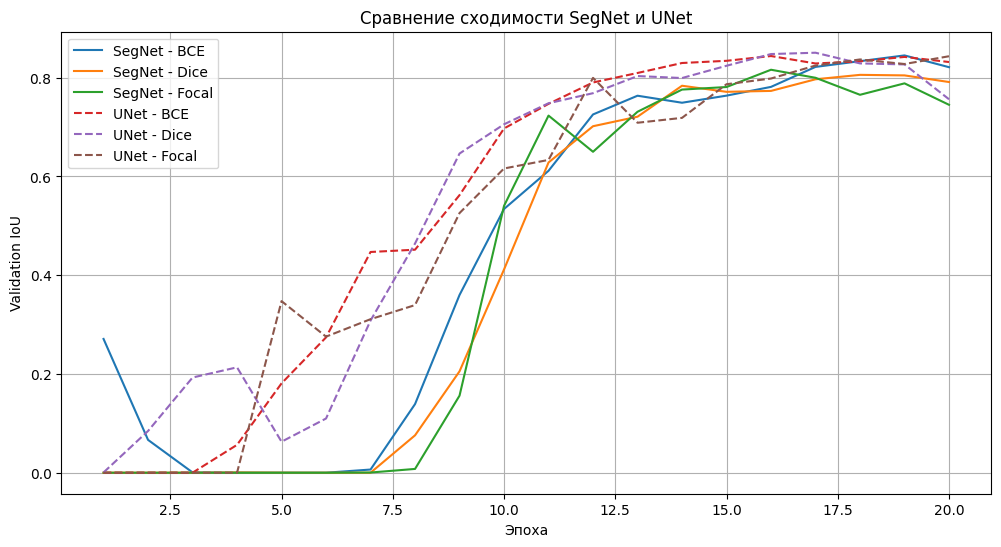

In [70]:
# Создаём df с итоговыми метриками на тесте
rows = []
for arch in ['SegNet', 'UNet']:
    for loss in loss_functions:
        rows.append({
            'Architecture': arch,
            'Loss': loss,
            'Test Loss': history[arch][loss]['test_loss'],
            'Test IoU': history[arch][loss]['test_iou']
        })
df = pd.DataFrame(rows)
print("\nСравнение архитектур и функций потерь:")
print(df.to_string(index=False))

# График валидационного IoU по эпохам для каждой архитектуры/лосса
plt.figure(figsize=(12, 6))
for arch in ['SegNet', 'UNet']:
    for loss in loss_functions:
        plt.plot(range(1, num_epochs+1), history[arch][loss]['val_iou'],
                 label=f'{arch} - {loss}', linestyle='-' if arch=='SegNet' else '--')
plt.xlabel('Эпоха')
plt.ylabel('Validation IoU')
plt.title('Сравнение сходимости SegNet и UNet')
plt.legend()
plt.grid(True)
plt.show()

Выводы на основании 20 эпох:
1. UNet превосходит SegNet по максимальному IoU
Лучший результат показала связка UNet + BCE: IoU 0.848 против 0.822 у SegNet.
Skip-соединения UNet лучше сохраняют пространственные детали, что даёт прирост качества.

2. UNet более чувствителен к выбору loss-функции
Разброс IoU у UNet: от 0.754 (Dice) до 0.848 (BCE).
У SegNet разброс меньше: 0.747–0.822. Особенно сильно UNet просел на Dice.

3. Focal Loss "заработал" только с UNet
SegNet + Focal дал всего 0.747 IoU, а UNet + Focal - уже 0.833 (почти на уровне BCE).
Это говорит о том, что UNet лучше использует механизм фокусировки на трудных примерах, однако даже в этом случае BCE остался лидером.

4. По поводу скорости моделей:

- С BCE обе архитектуры сходятся примерно одинаково быстро: SegNet достигает IoU >0.8 к 13-й эпохе, UNet - к 12-й (у UNet на 12-й эпохе уже 0.7903, на 13-й 0.8095);

- С Focal Loss UNet учится значительно быстрее SegNet: UNet уже к 12-й эпохе имеет IoU 0.7997, тогда как SegNet с Focal лишь к 22-й эпохе превысил 0.8.

- Dice Loss на UNet показывает быстрый взлёт к 16–17 эпохам (IoU до 0.85), но затем резко падает - это говорит о нестабильности и плохом обобщении, в отличие от более монотонного (хотя и медленного) обучения SegNet с Dice.

5. BCE остаётся наиболее универсальным и надёжным выбором
На этих данных обе архитектуры достигли с BCE лучших результатов.
Специализированные лоссы (Dice, Focal) не дали стабильного выигрыша, а в ряде случаев ухудшили метрику.